#Dataset Healthcare Insurance:**

**xAI **- Explainable Artificial Intelligence


## by: Pedro de Sousa Sebastiao.
June, 2026

**1. PREPARAÇÃO E CARREGAMENTO DOS DADOS**

In [2]:
#=====================================================
# BLOCO 1 – CARREGAMENTO DOS DADOS
#======================================================
import os
import pandas as pd

# Instalar bibliotecas
!pip install shap lime -q

# Bibliotecas principais
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# OPÇÃO 1: Dados no Google Drive
file_path = '/content/drive/MyDrive/datasets/Healthcare_Insurance_xAI/insurance.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Dados carregados: {df.shape[0]} amostras, {df.shape[1]} colunas")
else:
    # OPÇÃO 2: Upload manual (clique no ícone de pasta e faça upload)
    from google.colab import files
    print("Faça o upload do arquivo CSV:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    print(f"Upload concluído: {df.shape[0]} amostras")

# ---------------------------------------------------------------------------
# Carregar o dataset a partir do site
# ---------------------------------------------------------------------------

#url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"


# ---------------------------------------------------------------------------
# Verificação inicial
# ---------------------------------------------------------------------------

print("="*60)
print("DADOS CARREGADOS")
print("="*60)

print(f"Dimensão do dataset: {df.shape}")


print("\nPrimeiras amostras:")
print("-"*60)
print(df.head())


print("\nTipos das variáveis:")
print("-"*60)
print(df.dtypes)


print("\nValores ausentes:")
print("-"*60)
print(df.isnull().sum())

Mounted at /content/drive
Dados carregados: 1338 amostras, 7 colunas
DADOS CARREGADOS
Dimensão do dataset: (1338, 7)

Primeiras amostras:
------------------------------------------------------------
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Tipos das variáveis:
------------------------------------------------------------
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Valores ausentes:
------------------------------------------------------------
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dt

**2. PRÉ-PROCESAMENTO**

In [3]:
# =============================================================================
# BLOCO 2 - PRÉ-PROCESSAMENTO
# =============================================================================

# Criar cópia do dataset
df_processed = df.copy()

# Variáveis categóricas
categorical_cols = [
    "sex",
    "smoker",
    "region"
]

# Dicionário para armazenar os encoders
label_encoders = {}

# Aplicar Label Encoding
for col in categorical_cols:
    encoder = LabelEncoder()
    df_processed[col] = encoder.fit_transform(df_processed[col])
    label_encoders[col] = encoder

# Separar variáveis independentes e alvo
X = df_processed.drop("charges", axis=1)
y = df_processed["charges"]


print("="*60)
print("PRÉ-PROCESSAMENTO CONCLUÍDO")
print("="*60)

print("Features utilizadas:")
print(list(X.columns))

print("\nPrimeiras linhas processadas:")
print(X.head())

PRÉ-PROCESSAMENTO CONCLUÍDO
Features utilizadas:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Primeiras linhas processadas:
   age  sex     bmi  children  smoker  region
0   19    0  27.900         0       1       3
1   18    1  33.770         1       0       2
2   28    1  33.000         3       0       2
3   33    1  22.705         0       0       1
4   32    1  28.880         0       0       1


**3. DIVISÃO DADOS DE TREINO E TESTE**

In [4]:
# =============================================================================
# BLOCO 3 - DIVISÃO TREINO E TESTE
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*60)
print("DIVISÃO DOS DADOS")
print("="*60)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

DIVISÃO DOS DADOS
X_train: (1070, 6)
X_test:  (268, 6)
y_train: (1070,)
y_test:  (268,)


**4. TREINAMENTO RANDOM FOREST**

In [5]:
# =============================================================================
# BLOCO 4 - TREINAMENTO DO RANDOM FOREST
# =============================================================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state= 42
)

# Treinamento
model.fit(X_train, y_train)


# Predições
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


# Métricas
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)
rmse_test = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

print("="*60)
print("DESEMPENHO DO RANDOM FOREST")
print("="*60)

print(f"R² Treino : {r2_train:.4f}")
print(f"R² Teste  : {r2_test:.4f}")
print()

print(f"RMSE Treino: {rmse_train:.2f}")
print(f"RMSE Teste : {rmse_test:.2f}")

DESEMPENHO DO RANDOM FOREST
R² Treino : 0.9743
R² Teste  : 0.8643

RMSE Treino: 1925.62
RMSE Teste : 4590.57


**5. FEATURES SELECTION**

In [6]:
# =============================================================================
# BLOCO 5 - SELEÇÃO DAS 3 INSTÂNCIAS REAIS
# =============================================================================

# ----------------------------------------------------------------------
# 1. Ordenar o dataset original pelo valor real de 'charges'
# -----------------------------------------------------------------------

df_sorted = df.sort_values(by="charges").reset_index(drop=True)
# -------------------------------------------------------------------------
# 2. Dividir o dataset em três faixas
# -------------------------------------------------------------------------

n_samples = len(df_sorted)
part_size = n_samples // 3
lower_group = df_sorted.iloc[:part_size]
middle_group = df_sorted.iloc[part_size:2*part_size]
upper_group = df_sorted.iloc[2*part_size:]


# -------------------------------------------------------------------------
# 3. Selecionar a instância mediana de cada faixa
# ----------------------------------------------------------------------
instances_original = pd.DataFrame([
    lower_group.iloc[len(lower_group)//2],
    middle_group.iloc[len(middle_group)//2],
    upper_group.iloc[len(upper_group)//2]
]).reset_index(drop=True)

# -------------------------------------------------------------------------
# 4. Mostrar as três instâncias reais selecionadas
# -------------------------------------------------------------------------

print("="*70)
print("INSTÂNCIAS REAIS SELECIONADAS")
print("="*70)

print(instances_original)

INSTÂNCIAS REAIS SELECIONADAS
   age     sex     bmi  children smoker     region      charges
0   26  female  29.920         1     no  southeast   3392.97680
1   51    male  35.970         1     no  southeast   9386.16130
2   47  female  26.125         1    yes  northeast  23401.30575


**6. PREPARATION OF INSTANCES TO THE MODEL**

In [7]:

# =============================================================================
# BLOCO 6 - PREPARAÇÃO DAS INSTÂNCIAS PARA O MODELO
# =============================================================================

# Copiar apenas as variáveis de entrada
instances_processed = instances_original.drop(
    columns=["charges"]
).copy()

# Aplicar exatamente os mesmos encoders usados no treino
for col in categorical_cols:
    instances_processed[col] = (label_encoders[col]
        .transform(instances_processed[col])
    )

# Garantir a mesma ordem das features do modelo
instances_processed = instances_processed[X.columns]

# Conferência final
print("="*70)
print("INSTÂNCIAS PROCESSADAS PARA RANDOM FOREST, SHAP E LIME")
print("="*70)

print(instances_processed)

print("\nDimensão:", instances_processed.shape)
print("Features:", list(instances_processed.columns))


INSTÂNCIAS PROCESSADAS PARA RANDOM FOREST, SHAP E LIME
   age  sex     bmi  children  smoker  region
0   26    0  29.920         1       0       2
1   51    1  35.970         1       0       2
2   47    0  26.125         1       1       0

Dimensão: (3, 6)
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']


**7. EXPLICAÇÃO LOCAL SHAP**

RESULTADOS NUMÉRICOS - SHAP LOCAL


---------------------------------------------------------------------------
INSTÂNCIA 1
Charges real     : 3392.98
Charges previsto : 3680.25
---------------------------------------------------------------------------
    Feature  Valor         SHAP       |SHAP|
0    smoker   0.00 -4037.595609  4037.595609
1       age  26.00 -4025.505154  4025.505154
2       bmi  29.92 -1073.765447  1073.765447
3    region   2.00  -881.532782   881.532782
4       sex   0.00   235.345752   235.345752
5  children   1.00   113.889124   113.889124


---------------------------------------------------------------------------
INSTÂNCIA 2
Charges real     : 9386.16
Charges previsto : 9337.99
---------------------------------------------------------------------------
    Feature  Valor         SHAP       |SHAP|
0    smoker   0.00 -5988.575261  5988.575261
1       age  51.00  1576.547915  1576.547915
2       bmi  35.97  1136.068954  1136.068954
3    region   2.00  -762.867523

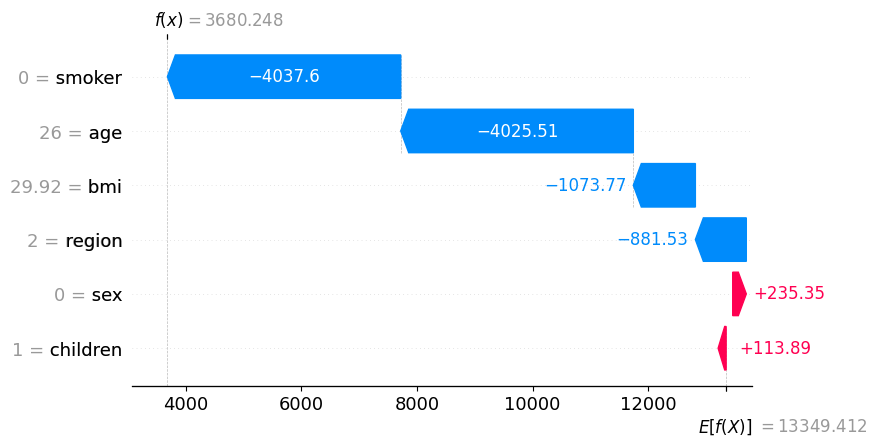



GRÁFICO SHAP - INSTÂNCIA 2


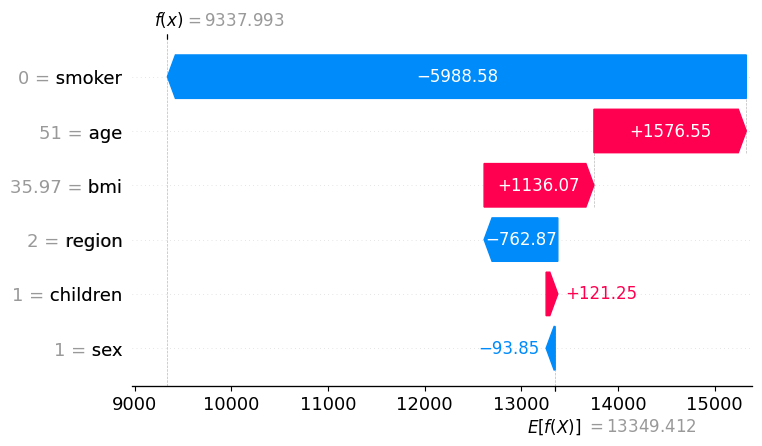



GRÁFICO SHAP - INSTÂNCIA 3


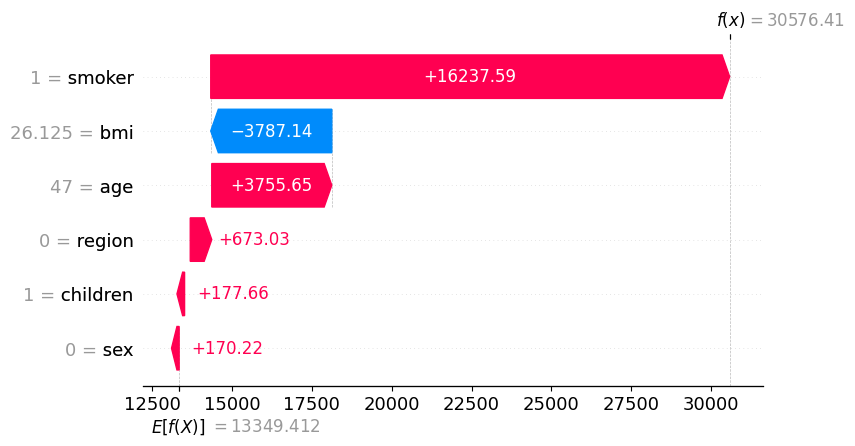

In [8]:
# =============================================================================
# BLOCO 7 - EXPLICAÇÃO LOCAL SHAP
# =============================================================================

import shap
# -------------------------------------------------------------------------
# 1. Criar explicador SHAP
# -------------------------------------------------------------------------

explainer_shap = shap.TreeExplainer(model)
# -------------------------------------------------------------------------
# 2. Calcular valores SHAP das três instâncias
# -------------------------------------------------------------------------

shap_values_local = explainer_shap(instances_processed)
predictions = model.predict(instances_processed)
# -------------------------------------------------------------------------
# 3. Organizar resultados numéricos
# -------------------------------------------------------------------------

shap_tables = []

print("="*75)
print("RESULTADOS NUMÉRICOS - SHAP LOCAL")
print("="*75)

for i in range(len(instances_processed)):
    temp_df = pd.DataFrame({
        "Feature": X.columns,
        "Valor": instances_processed.iloc[i].values,
        "SHAP": shap_values_local.values[i]
    })

    temp_df["|SHAP|"] = np.abs(temp_df["SHAP"])

    temp_df = temp_df.sort_values(
        "|SHAP|",
        ascending=False
    ).reset_index(drop=True)

    shap_tables.append(temp_df)

    print("\n")
    print("-"*75)
    print(f"INSTÂNCIA {i+1}")
    print(f"Charges real     : {instances_original.loc[i,'charges']:.2f}")
    print(f"Charges previsto : {predictions[i]:.2f}")
    print("-"*75)

    print(temp_df)

# -------------------------------------------------------------------------
# 4. Gráficos SHAP (depois da análise numérica)
# -------------------------------------------------------------------------
for i in range(len(instances_processed)):

    print("\n")
    print("="*75)
    print(f"GRÁFICO SHAP - INSTÂNCIA {i+1}")
    print("="*75)

    shap.plots.waterfall(
        shap_values_local[i],
        max_display=len(X.columns)
    )

**8. LIME EXPLANATION**

RESULTADOS NUMÉRICOS - LIME LOCAL


---------------------------------------------------------------------------
INSTÂNCIA 1
---------------------------------------------------------------------------
              Feature_LIME          LIME        |LIME|
0           smoker <= 0.00 -22261.057066  22261.057066
1             age <= 27.00  -5344.621487   5344.621487
2     26.20 < bmi <= 30.21  -2395.471566   2395.471566
3  0.00 < children <= 1.00    383.271577    383.271577
4    1.00 < region <= 2.00   -376.700282    376.700282
5              sex <= 0.00    341.823571    341.823571


---------------------------------------------------------------------------
INSTÂNCIA 2
---------------------------------------------------------------------------
              Feature_LIME          LIME        |LIME|
0           smoker <= 0.00 -23905.914464  23905.914464
1              bmi > 34.50   3527.772407   3527.772407
2     39.50 < age <= 51.00   1236.648040   1236.648040
3    1.00 < region <= 2.00   

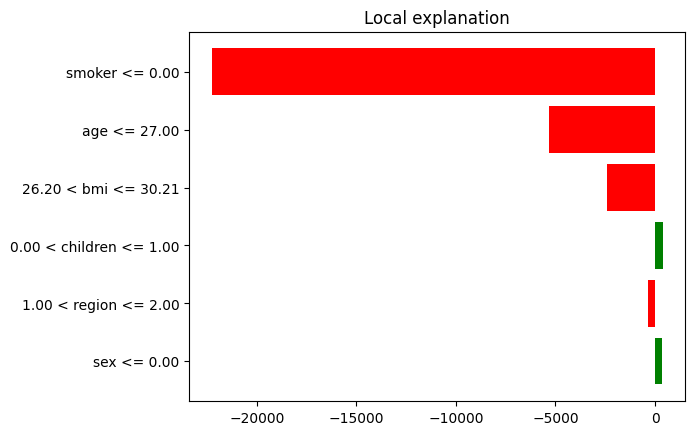



GRÁFICO LIME - INSTÂNCIA 2


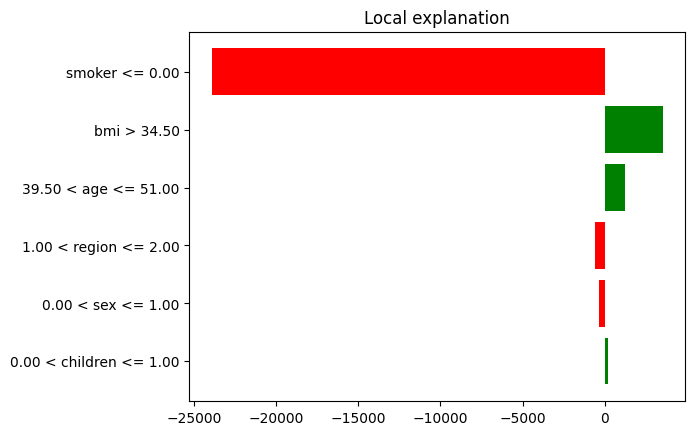



GRÁFICO LIME - INSTÂNCIA 3


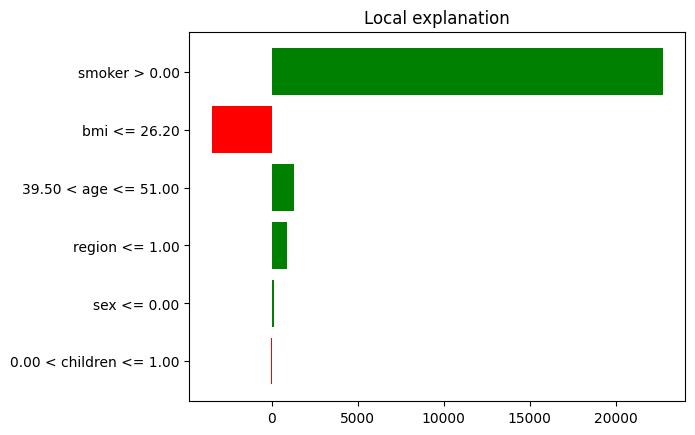

In [9]:
# =============================================================================
# BLOCO 8 - EXPLICAÇÃO LOCAL LIME
# =============================================================================
import lime
import lime.lime_tabular
# -------------------------------------------------------------------------
# Wrapper para preservar os nomes das variáveis
# -------------------------------------------------------------------------
def predict_lime(data):
    data_df = pd.DataFrame(
        data,
        columns=X.columns
    )
    return model.predict(data_df)
# -------------------------------------------------------------------------
# Criar explicador LIME
# -------------------------------------------------------------------------

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    mode="regression",
    random_state=42
)

lime_tables = []
lime_explanations = []

print("="*75)
print("RESULTADOS NUMÉRICOS - LIME LOCAL")
print("="*75)

for i in range(len(instances_processed)):

    explanation = explainer_lime.explain_instance(
        data_row=instances_processed.iloc[i].values,
        predict_fn=predict_lime,
        num_features=len(X.columns)
    )

    lime_explanations.append(explanation)

    temp_df = pd.DataFrame(
        explanation.as_list(),
        columns=["Feature_LIME", "LIME"]
    )

    temp_df["|LIME|"] = np.abs(temp_df["LIME"])
    temp_df = temp_df.sort_values(
        "|LIME|",
        ascending=False
    ).reset_index(drop=True)

    lime_tables.append(temp_df)

    print("\n")
    print("-"*75)
    print(f"INSTÂNCIA {i+1}")
    print("-"*75)

    print(temp_df)
# -------------------------------------------------------------------------
# Gráficos LIME após análise numérica
# -------------------------------------------------------------------------
for i, explanation in enumerate(lime_explanations):

    print("\n")
    print("="*75)
    print(f"GRÁFICO LIME - INSTÂNCIA {i+1}")
    print("="*75)

    fig = explanation.as_pyplot_figure()
    plt.show()

**9. COMPARAÇÃO LIME VS. SHAP**

In [10]:
# =============================================================================
# BLOCO 9 - TABELA DE COMPARAÇÃO SHAP x LIME
# =============================================================================

for i in range(3):

    print("\n")
    print("="*90)
    print(f"COMPARAÇÃO LOCAL - INSTÂNCIA {i+1}")
    print("="*90)


    print("\nSHAP")
    print(
        shap_tables[i][
            ["Feature", "SHAP", "|SHAP|"]
        ]
    )

    print("\nLIME")
    print(
        lime_tables[i][
            ["Feature_LIME", "LIME", "|LIME|"]
        ]
    )



COMPARAÇÃO LOCAL - INSTÂNCIA 1

SHAP
    Feature         SHAP       |SHAP|
0    smoker -4037.595609  4037.595609
1       age -4025.505154  4025.505154
2       bmi -1073.765447  1073.765447
3    region  -881.532782   881.532782
4       sex   235.345752   235.345752
5  children   113.889124   113.889124

LIME
              Feature_LIME          LIME        |LIME|
0           smoker <= 0.00 -22261.057066  22261.057066
1             age <= 27.00  -5344.621487   5344.621487
2     26.20 < bmi <= 30.21  -2395.471566   2395.471566
3  0.00 < children <= 1.00    383.271577    383.271577
4    1.00 < region <= 2.00   -376.700282    376.700282
5              sex <= 0.00    341.823571    341.823571


COMPARAÇÃO LOCAL - INSTÂNCIA 2

SHAP
    Feature         SHAP       |SHAP|
0    smoker -5988.575261  5988.575261
1       age  1576.547915  1576.547915
2       bmi  1136.068954  1136.068954
3    region  -762.867523   762.867523
4  children   121.252771   121.252771
5       sex   -93.846783    93.846783

**10. COMOPARAÇÃO SHAP VS LIME**



COMPARAÇÃO SHAP × LIME - INSTÂNCIA 1


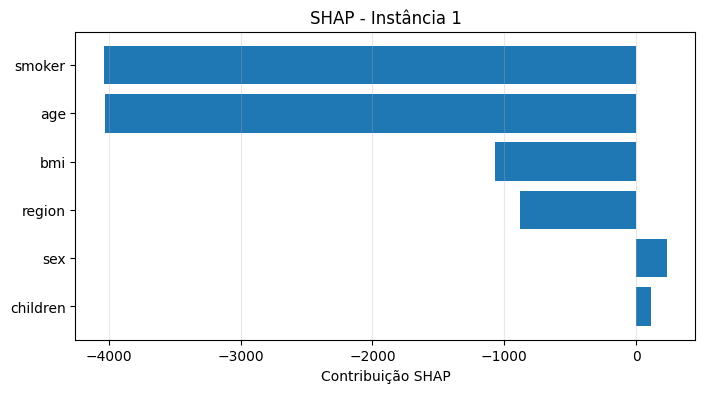

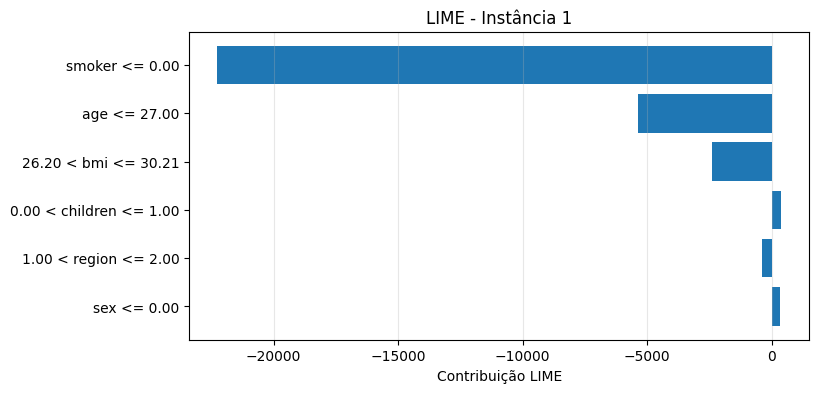



COMPARAÇÃO SHAP × LIME - INSTÂNCIA 2


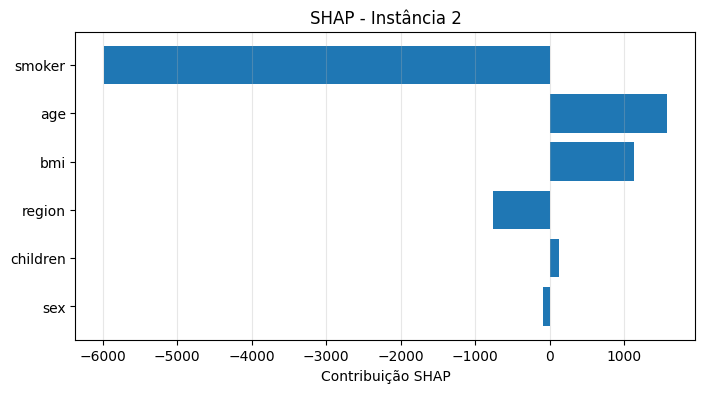

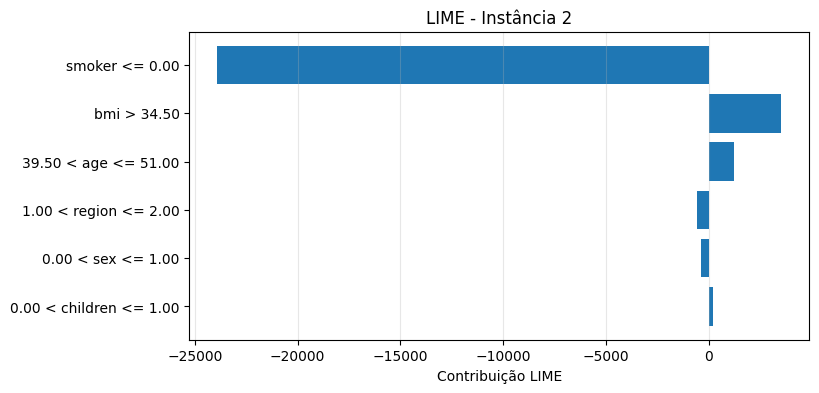



COMPARAÇÃO SHAP × LIME - INSTÂNCIA 3


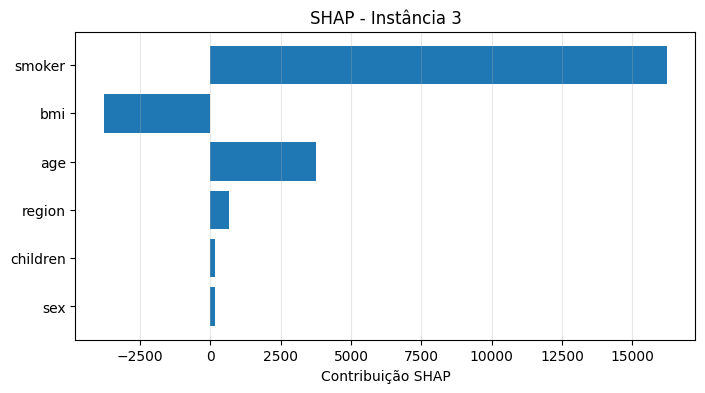

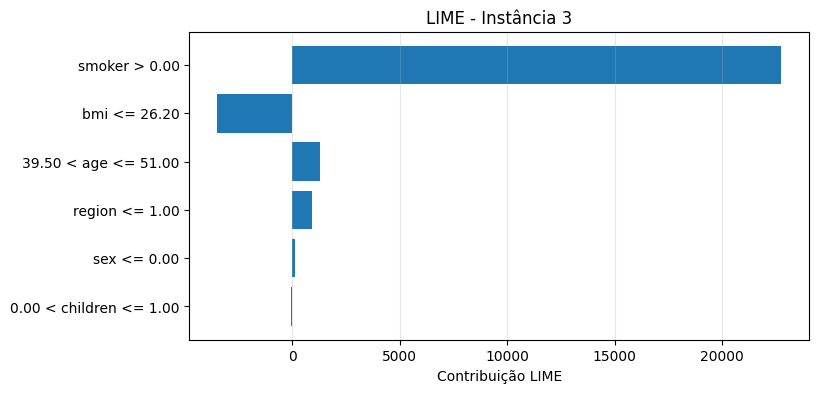

In [11]:
# =============================================================================
# BLOCO 10 - COMPARAÇÃO GRÁFICA SHAP vs. LIME
# ==========================================================================

for i in range(3):
    print("\n")
    print("="*80)
    print(f"COMPARAÇÃO SHAP × LIME - INSTÂNCIA {i+1}")
    print("="*80)

    # -------------------------
    # Gráfico SHAP
    # -------------------------
    plt.figure(figsize=(8, 4))

    plt.barh(
        shap_tables[i]["Feature"],
        shap_tables[i]["SHAP"]
    )

    plt.xlabel("Contribuição SHAP")
    plt.title(f"SHAP - Instância {i+1}")

    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)

    plt.show()
    # -------------------------
    # Gráfico LIME
    # -------------------------
    plt.figure(figsize=(8, 4))

    plt.barh(
        lime_tables[i]["Feature_LIME"],
        lime_tables[i]["LIME"]
    )

    plt.xlabel("Contribuição LIME")
    plt.title(f"LIME - Instância {i+1}")

    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)

    plt.show()

**11. SHAP GLOBAL**

SHAP GLOBAL - SUMMARY PLOT


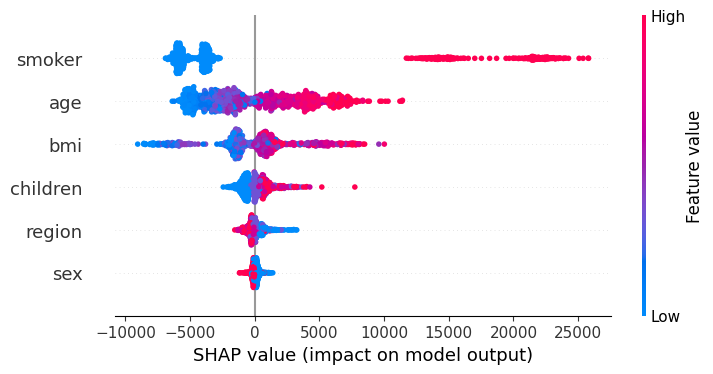



RANKING GLOBAL DAS VARIÁVEIS
    Feature  Mean |SHAP|
0    smoker  7625.860691
1       age  3378.894559
2       bmi  2278.934861
3  children   740.121298
4    region   420.709287
5       sex   176.033285


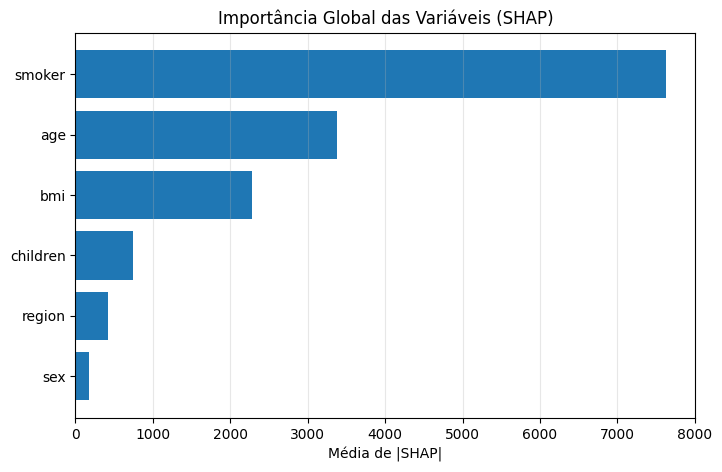

In [12]:
# =============================================================================
# BLOCO 11 - EXPLICAÇÃO GLOBAL COM SHAP
# =============================================================================

# -------------------------------------------------------------------------
# 1. Calcular SHAP para todos os dados de treino
# -------------------------------------------------------------------------

shap_values_global = explainer_shap(X_train)
# -------------------------------------------------------------------------
# 2. Gráfico summary plot (beeswarm)
# -------------------------------------------------------------------------
print("="*80)
print("SHAP GLOBAL - SUMMARY PLOT")
print("="*80)

shap.plots.beeswarm(
    shap_values_global,
    max_display=len(X.columns)
)
# -------------------------------------------------------------------------
# 3. Calcular importância média absoluta
# -------------------------------------------------------------------------

global_importance = pd.DataFrame({

    "Feature": X.columns,
    "Mean |SHAP|":
        np.abs(
            shap_values_global.values
        ).mean(axis=0)

})

global_importance = global_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
).reset_index(drop=True)


# -------------------------------------------------------------------------
# 4. Apresentar ranking numérico
# -------------------------------------------------------------------------

print("\n")
print("="*80)
print("RANKING GLOBAL DAS VARIÁVEIS")
print("="*80)

print(global_importance)

# -------------------------------------------------------------------------
# 5. Gráfico de barras da importância global
# -------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.barh(
    global_importance["Feature"],
    global_importance["Mean |SHAP|"]
)

plt.gca().invert_yaxis()

plt.xlabel("Média de |SHAP|")
plt.title("Importância Global das Variáveis (SHAP)")

plt.grid(axis="x", alpha=0.3)

plt.show()

**TESTE COM REDES NEURAIS**

In [13]:
# =============================================================================
# BLOCO 13 - NORMALIZAÇÃO PARA REDE NEURAL
# =============================================================================

from sklearn.preprocessing import StandardScaler

# Criar o scaler
scaler = StandardScaler()

# Ajustar apenas no treino
X_train_nn = scaler.fit_transform(X_train)

# Transformar o teste
X_test_nn = scaler.transform(X_test)

# Também transformar as três instâncias usadas na explicação
instances_nn = scaler.transform(instances_processed)


print("="*70)
print("DADOS PREPARADOS PARA A REDE NEURAL")
print("="*70)

print("Treino:", X_train_nn.shape)
print("Teste :", X_test_nn.shape)
print("Instâncias para explicação:", instances_nn.shape)

DADOS PREPARADOS PARA A REDE NEURAL
Treino: (1070, 6)
Teste : (268, 6)
Instâncias para explicação: (3, 6)


MLP ReLU

In [14]:
# =============================================================================
# BLOCO 14 - TREINAMENTO DA REDE NEURAL
# =============================================================================

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error
)
import numpy as np


# Criar o modelo
model_nn = MLPRegressor(
    hidden_layer_sizes=(32,16),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42
)


# Treinar
model_nn.fit(X_train_nn, y_train)


# Predições
y_train_pred_nn = model_nn.predict(X_train_nn)
y_test_pred_nn = model_nn.predict(X_test_nn)


# Métricas
r2_train_nn = r2_score(y_train, y_train_pred_nn)
r2_test_nn = r2_score(y_test, y_test_pred_nn)

rmse_train_nn = np.sqrt(
    mean_squared_error(y_train, y_train_pred_nn)
)

rmse_test_nn = np.sqrt(
    mean_squared_error(y_test, y_test_pred_nn)
)


print("="*70)
print("DESEMPENHO DA REDE NEURAL")
print("="*70)

print(f"R² treino: {r2_train_nn:.4f}")
print(f"R² teste : {r2_test_nn:.4f}")

print()
print(f"RMSE treino: {rmse_train_nn:.2f}")
print(f"RMSE teste : {rmse_test_nn:.2f}")

DESEMPENHO DA REDE NEURAL
R² treino: 0.8521
R² teste : 0.8701

RMSE treino: 4620.07
RMSE teste : 4489.97


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


**15. PREDIÇÕES DA REDE NEURAL NAS 3 INSTÂNCIAS**

In [16]:
# =============================================================================
# BLOCO 15 - PREDIÇÕES DA REDE NEURAL NAS 3 INSTÂNCIAS
# =============================================================================

# Recuperar os valores reais de charges das 3 instâncias selecionadas

df_sorted = df.sort_values("charges").reset_index(drop=True)

n = len(df_sorted)
part_size = n // 3

real_instances = [
    df_sorted.iloc[len(df_sorted.iloc[:part_size]) // 2],
    df_sorted.iloc[part_size + len(df_sorted.iloc[part_size:2*part_size]) // 2],
    df_sorted.iloc[2*part_size + len(df_sorted.iloc[2*part_size:]) // 2]
]


print("="*70)
print("PREDIÇÕES DA REDE NEURAL PARA AS 3 INSTÂNCIAS")
print("="*70)


# Predições da MLP
predictions_nn = model_nn.predict(instances_nn)

# Armazenar erros
errors_nn = []

for i in range(3):

    real_value = real_instances[i]["charges"]
    predicted_value = predictions_nn[i]

    error = abs(real_value - predicted_value)
    errors_nn.append(error)

    print("\n" + "-"*60)
    print(f"INSTÂNCIA {i+1}")
    print("-"*60)

    print(f"Charges real     : {real_value:.2f}")
    print(f"Charges previsto : {predicted_value:.2f}")
    print(f"Erro absoluto    : {error:.2f}")


print("\n" + "="*70)
print("RESUMO DOS ERROS DA MLP")
print("="*70)

print(f"Erro médio absoluto: {np.mean(errors_nn):.2f}")
print(f"Maior erro absoluto: {np.max(errors_nn):.2f}")

PREDIÇÕES DA REDE NEURAL PARA AS 3 INSTÂNCIAS

------------------------------------------------------------
INSTÂNCIA 1
------------------------------------------------------------
Charges real     : 3392.98
Charges previsto : 4019.82
Erro absoluto    : 626.84

------------------------------------------------------------
INSTÂNCIA 2
------------------------------------------------------------
Charges real     : 9386.16
Charges previsto : 11543.47
Erro absoluto    : 2157.31

------------------------------------------------------------
INSTÂNCIA 3
------------------------------------------------------------
Charges real     : 23401.31
Charges previsto : 24403.57
Erro absoluto    : 1002.26

RESUMO DOS ERROS DA MLP
Erro médio absoluto: 1262.14
Maior erro absoluto: 2157.31


**16. EXPLICAÇÕES LOCAIS COM LIME PARA A REDE NEURAL**


LIME LOCAL - REDE NEURAL (MLP)

LIME LOCAL MLP - INSTÂNCIA 1
Contribuições das variáveis:
             Feature_LIME          LIME
          smoker <= -0.51 -22421.904152
             age <= -0.88  -6177.439109
     -0.72 < bmi <= -0.06  -2045.574863
   -0.46 < region <= 0.44   -533.291331
             sex <= -1.02   -389.170637
-0.91 < children <= -0.09   -220.393706


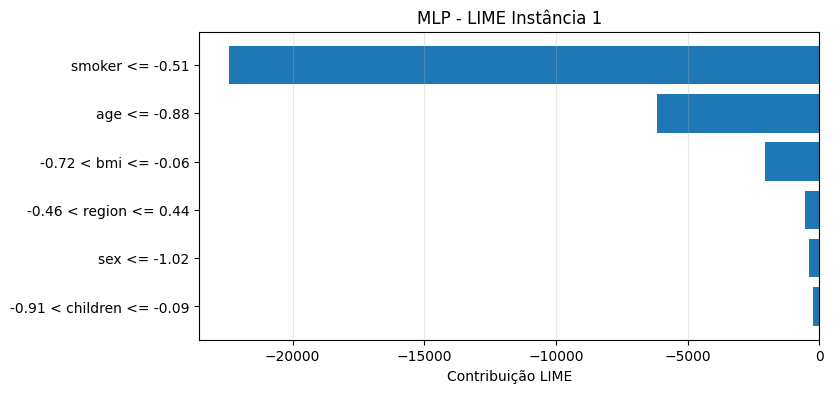


LIME LOCAL MLP - INSTÂNCIA 2
Contribuições das variáveis:
             Feature_LIME          LIME
          smoker <= -0.51 -23770.327573
               bmi > 0.65   5716.937007
       0.01 < age <= 0.83   1459.259285
   -0.46 < region <= 0.44   -760.919355
-0.91 < children <= -0.09   -439.153340
      -1.02 < sex <= 0.98    101.180591


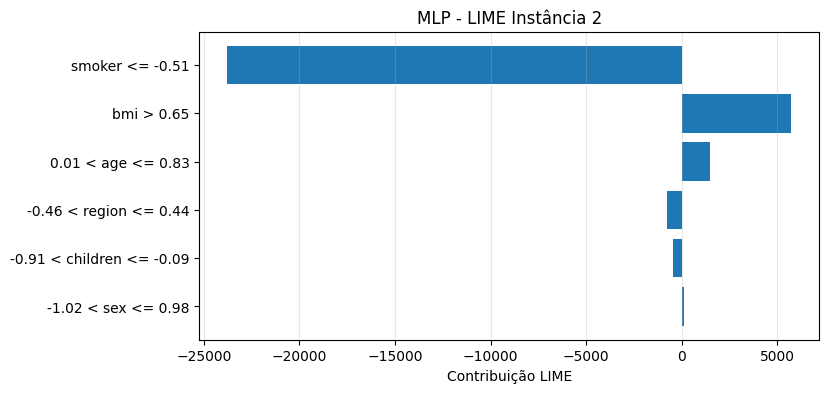


LIME LOCAL MLP - INSTÂNCIA 3
Contribuições das variáveis:
             Feature_LIME         LIME
           smoker > -0.51 22753.488031
             bmi <= -0.72 -5061.944325
       0.01 < age <= 0.83  1702.204406
          region <= -0.46   630.271561
-0.91 < children <= -0.09  -611.886378
             sex <= -1.02  -369.888429


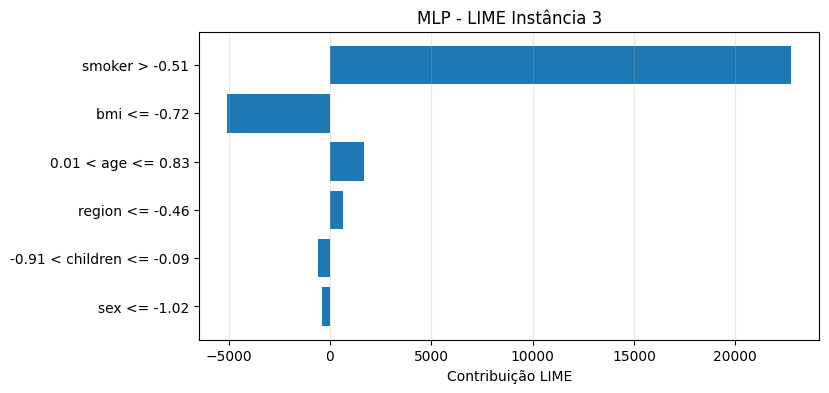

In [17]:
# =============================================================================
# BLOCO 16 - EXPLICAÇÕES LOCAIS COM LIME PARA A REDE NEURAL
# =============================================================================

import lime
import lime.lime_tabular


print("\n" + "="*70)
print("LIME LOCAL - REDE NEURAL (MLP)")
print("="*70)

# -------------------------------------------------------------------------
# Criar o explicador LIME
# -------------------------------------------------------------------------

explainer_lime_nn = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_nn,
    feature_names=list(X.columns),
    mode="regression",
    random_state=42
)


# Guardar explicações
lime_tables_nn = []


# -------------------------------------------------------------------------
# Explicar cada uma das três instâncias
# -------------------------------------------------------------------------

for i in range(3):

    print("\n" + "="*70)
    print(f"LIME LOCAL MLP - INSTÂNCIA {i+1}")
    print("="*70)


    exp = explainer_lime_nn.explain_instance(
        data_row=instances_nn[i],
        predict_fn=model_nn.predict,
        num_features=len(X.columns)
    )


    # Converter explicação em DataFrame
    lime_df = (
        pd.DataFrame(
            exp.as_list(),
            columns=["Feature_LIME", "LIME"]
        )
        .sort_values(
            by="LIME",
            key=np.abs,
            ascending=False
        )
        .reset_index(drop=True)
    )


    lime_tables_nn.append(lime_df)


    print("Contribuições das variáveis:")
    print(lime_df.to_string(index=False))


    # Gráfico
    plt.figure(figsize=(8,4))

    plt.barh(
        lime_df["Feature_LIME"],
        lime_df["LIME"]
    )

    plt.gca().invert_yaxis()
    plt.xlabel("Contribuição LIME")
    plt.title(f"MLP - LIME Instância {i+1}")
    plt.grid(axis="x", alpha=0.3)

    plt.show()

**17. SHAP LOCAL PARA REDE NEURAL**


SHAP LOCAL - REDE NEURAL (MLP)


  0%|          | 0/3 [00:00<?, ?it/s]


SHAP LOCAL MLP - INSTÂNCIA 1
Contribuições das variáveis:
 Feature         SHAP
  smoker -5001.236994
     age -3728.832225
  region  -748.682636
     bmi  -654.054411
     sex   394.599481
children  -238.778604


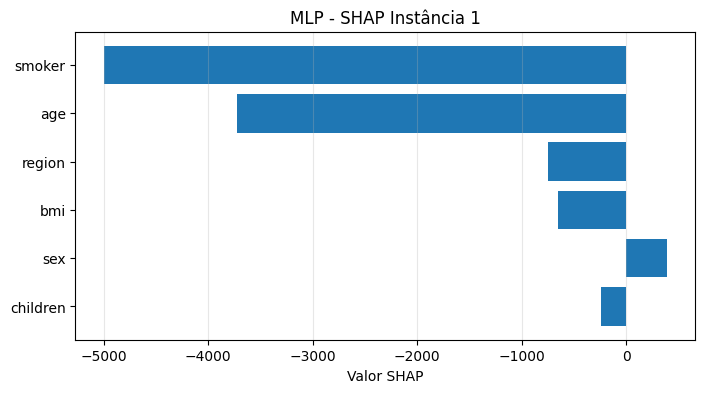


SHAP LOCAL MLP - INSTÂNCIA 2
Contribuições das variáveis:
 Feature         SHAP
  smoker -5980.789332
     age  2957.109358
     bmi  1105.409739
  region  -318.929109
children  -234.127981
     sex    17.991237


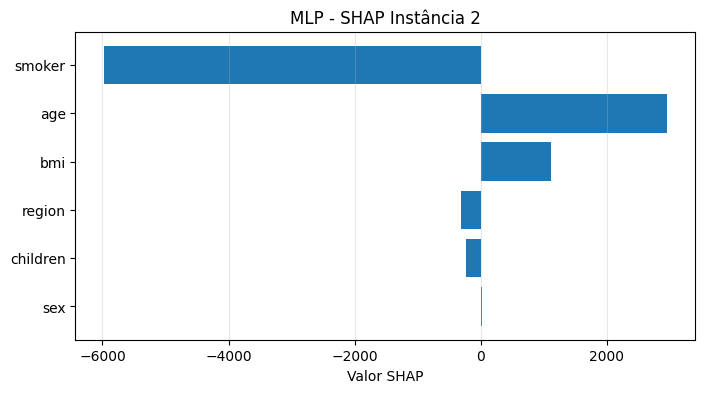


SHAP LOCAL MLP - INSTÂNCIA 3
Contribuições das variáveis:
 Feature         SHAP
  smoker 14998.518183
     bmi -5828.299727
     age  1549.257915
     sex  -530.938132
  region   365.178589
children  -146.950841


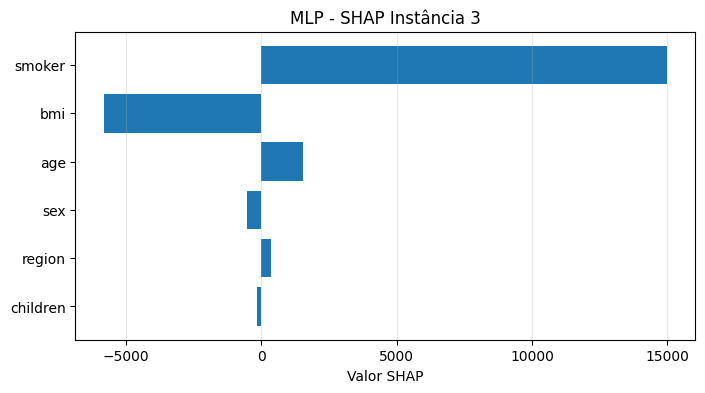

In [18]:
# =============================================================================
# BLOCO 17 - SHAP LOCAL PARA REDE NEURAL (KernelExplainer)
# =============================================================================

print("\n" + "="*70)
print("SHAP LOCAL - REDE NEURAL (MLP)")
print("="*70)

# -------------------------------------------------------------------------
# Selecionar um background reduzido
# -------------------------------------------------------------------------

np.random.seed(42)

background_idx = np.random.choice(
    X_train_nn.shape[0],
    size=100,
    replace=False
)

background = X_train_nn[background_idx]

# -------------------------------------------------------------------------
# Criar o explicador SHAP
# -------------------------------------------------------------------------
explainer_shap_nn = shap.KernelExplainer(
    model_nn.predict,
    background
)

# -------------------------------------------------------------------------
# Calcular SHAP para as 3 instâncias
# -------------------------------------------------------------------------
shap_values_nn = explainer_shap_nn.shap_values(
    instances_nn,
    nsamples=200
)

# Guardar tabelas
shap_tables_nn = []


for i in range(3):

    print("\n" + "="*70)
    print(f"SHAP LOCAL MLP - INSTÂNCIA {i+1}")
    print("="*70)


    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "SHAP": shap_values_nn[i]
    })

    shap_df["ABS"] = np.abs(shap_df["SHAP"])

    shap_df = (
        shap_df
        .sort_values(
            "ABS",
            ascending=False
        )
        .drop(
            columns="ABS"
        )
        .reset_index(drop=True)
    )


    shap_tables_nn.append(shap_df)


    print("Contribuições das variáveis:")
    print(shap_df.to_string(index=False))


    # Gráfico de barras
    plt.figure(figsize=(8,4))

    plt.barh(
        shap_df["Feature"],
        shap_df["SHAP"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Valor SHAP")
    plt.title(f"MLP - SHAP Instância {i+1}")

    plt.grid(axis="x", alpha=0.3)

    plt.show()

**18. SHAP GLOBAL DA REDE NEURAL**

In [19]:
# =============================================================================
# BLOCO 18.1 - SHAP GLOBAL DA REDE NEURAL
# =============================================================================

print("\n" + "="*70)
print("SHAP GLOBAL - REDE NEURAL (MLP)")
print("="*70)

# -------------------------------------------------------------------------
# Selecionar amostra do conjunto de treino
# -------------------------------------------------------------------------

np.random.seed(42)

sample_size = 200

sample_idx = np.random.choice(
    X_train_nn.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_train_nn[sample_idx]

print(f"Número de amostras utilizadas: {len(X_sample)}")
# -------------------------------------------------------------------------
# Calcular valores SHAP
# -------------------------------------------------------------------------
shap_values_global_nn = explainer_shap_nn.shap_values(
    X_sample,
    nsamples=200
)

print("Valores SHAP calculados com sucesso.")


SHAP GLOBAL - REDE NEURAL (MLP)
Número de amostras utilizadas: 200


  0%|          | 0/200 [00:00<?, ?it/s]

Valores SHAP calculados com sucesso.


/tmp/ipykernel_9762/3375347035.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


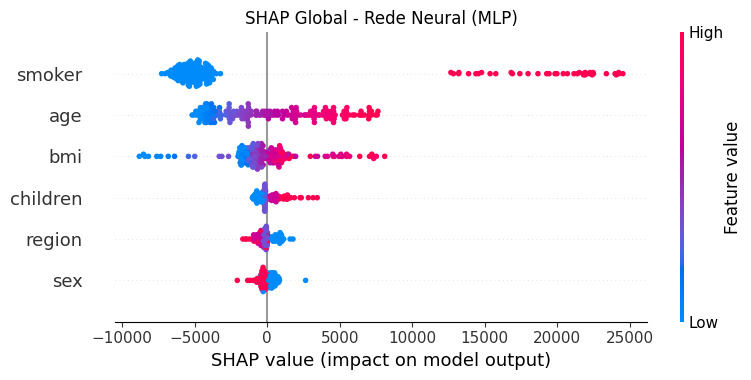

In [20]:
# =============================================================================
# BLOCO 18.2 - SHAP BEESWARM
# =============================================================================
shap.summary_plot(
    shap_values_global_nn,
    X_sample,
    feature_names=X.columns,
    show=False
)

plt.title("SHAP Global - Rede Neural (MLP)")
plt.tight_layout()
plt.show()

In [22]:
# =============================================================================
# BLOCO 18.3 - IMPORTÂNCIA GLOBAL NUMÉRICA
# =============================================================================

mean_abs_shap_nn = np.abs(
    shap_values_global_nn
).mean(axis=0)


importance_nn = pd.DataFrame({

    "Feature": X.columns,
    "Mean Abs SHAP": mean_abs_shap_nn

})

importance_nn = importance_nn.sort_values(
    "Mean Abs SHAP",
    ascending=False
).reset_index(drop=True)


print("\n")
print("="*70)
print("IMPORTÂNCIA GLOBAL DAS FEATURES - MLP")
print("="*70)

print(importance_nn)



IMPORTÂNCIA GLOBAL DAS FEATURES - MLP
    Feature  Mean Abs SHAP
0    smoker    7984.102338
1       age    3231.760169
2       bmi    1783.756681
3  children     592.937290
4    region     456.806787
5       sex     367.685006


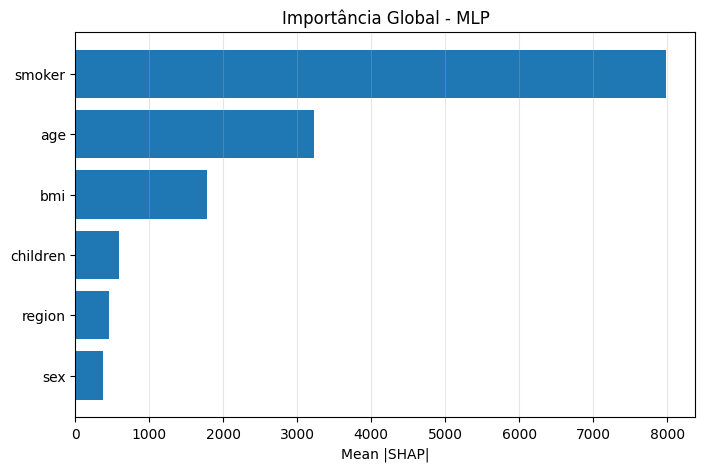

In [24]:
# =============================================================================
# BLOCO 18.4 - BARPLOT GLOBAL
# =============================================================================
plt.figure(figsize=(8,5))

plt.barh(
    importance_nn["Feature"],
    importance_nn["Mean Abs SHAP"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mean |SHAP|")
plt.title("Importância Global - MLP")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [30]:
# =============================================================================
# BLOCO 18.5 - COMPARAÇÃO RF x MLP
# =============================================================================

comparison_global = pd.merge(

    global_importance.rename(
        columns={"Mean abs SHAP":"Mean |SHAP|"}
    ),

    importance_nn.rename(
        columns={"Mean Abs SHAP":"MLP_SHAP"}
    ),

    on="Feature"

)

comparison_global["RF_Rank"] = (
    comparison_global["Mean |SHAP|"]
    .rank(ascending=False)
)

comparison_global["MLP_Rank"] = (
    comparison_global["MLP_SHAP"]
    .rank(ascending=False)
)

comparison_global = comparison_global.sort_values(
    "RF_Rank"
)

print("\n")
print("="*70)
print("COMPARAÇÃO GLOBAL RF x MLP")
print("="*70)

print(comparison_global)



COMPARAÇÃO GLOBAL RF x MLP
    Feature  Mean |SHAP|     MLP_SHAP  RF_Rank  MLP_Rank
0    smoker  7625.860691  7984.102338      1.0       1.0
1       age  3378.894559  3231.760169      2.0       2.0
2       bmi  2278.934861  1783.756681      3.0       3.0
3  children   740.121298   592.937290      4.0       4.0
4    region   420.709287   456.806787      5.0       5.0
5       sex   176.033285   367.685006      6.0       6.0
